### **Activaciones, normalización y arquitecturas profundas**

Los temas tratados en este cuaderno son:

- comparación inicial entre **modelo totalmente conectado** y **CNN**
- funciones de activación: `tanh`, `sigmoid`, `ReLU` y `LeakyReLU`
- **Batch Normalization** y **Layer Normalization**
- conexiones **residuales**, bloques `1x1` y bloques **residuales**
- comparación entre **RNN** y **LSTM** en una tarea de secuencias.


In [1]:
# Importaciones principales: PyTorch, utilidades del curso y librerías de visualización.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision 
from torchvision import transforms

from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

import pandas as pd

from sklearn.metrics import accuracy_score

import time

from utils import train_network, Flatten, weight_reset, set_seed
from utils import LanguageNameDataset, pad_and_pack, EmbeddingPackable, LastTimeStep, LambdaLayer

In [2]:
# Configuración de matplotlib para mostrar figuras nítidas dentro del cuaderno.
%matplotlib inline
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('png', 'pdf')
except Exception:
    pass

In [3]:
# Fijamos la semilla para obtener resultados reproducibles.
torch.backends.cudnn.deterministic=True
set_seed(42)

In [4]:
# Selección automática de dispositivo: GPU si está disponible, en caso contrario CPU.
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

#### **1. Carga de datos y definición de dimensiones**

En esta parte se carga **FashionMNIST** y se fijan las dimensiones básicas del problema:
- ancho y alto de la imagen
- tamaño del vector de entrada
- número de canales
- número de filtros
- número de clases


In [5]:
# Carga del conjunto de datos FashionMNIST y creación de los dataloaders.
train_data = torchvision.datasets.FashionMNIST("./", train=True, transform=transforms.ToTensor(), download=True)
test_data = torchvision.datasets.FashionMNIST("./", train=False, transform=transforms.ToTensor(), download=True)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26421880/26421880 [00:08<00:00, 2954429.16it/s]


Extracting ./FashionMNIST/raw/train-images-idx3-ubyte.gz to ./FashionMNIST/raw



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29515/29515 [00:00<00:00, 153571.66it/s]


Extracting ./FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./FashionMNIST/raw



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4422102/4422102 [00:03<00:00, 1145557.71it/s]


Extracting ./FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./FashionMNIST/raw



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5148/5148 [00:00<00:00, 3325470.04it/s]

Extracting ./FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./FashionMNIST/raw



In [6]:
# Parámetros básicos del problema de clasificación de imágenes.
# ¿Cuál es el ancho y alto de nuestras imágenes?
W, H = 28, 28 #
# ¿Cuántos valores tiene la entrada? Esto ayuda a definir el tamaño de las capas siguientes.
D = 28*28 #28 * 28 images 
# Tamaño de la capa oculta
n = 256 
# ¿Cuántos canales tiene la entrada?
C = 1
# ¿Cuántos filtros tendrá cada capa convolucional?
n_filters = 32
# ¿Cuántas clases hay?
classes = 10#

#### **2. Línea base: red totalmente conectada vs CNN**

Primero se construyen dos modelos base:
- una red **fully connected**
- una **CNN**

La idea es comparar qué tan bien aprende cada arquitectura antes de introducir mejoras.


In [7]:
# Modelo base totalmente conectado (fully connected) para usarlo como referencia.
fc_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.Tanh(),
    *[nn.Sequential(nn.Linear(n,  n),nn.Tanh()) for _ in range(5)],
    nn.Linear(n, classes),
)

In [8]:
# Modelo convolucional base (CNN) para comparar contra la red totalmente conectada.
cnn_model = nn.Sequential(
    nn.Conv2d(C, n_filters, 3, padding=1),             nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),     nn.Tanh(),
    nn.Conv2d(n_filters, n_filters, 3, padding=1),     nn.Tanh(),
    nn.MaxPool2d((2,2)),
    nn.Conv2d(  n_filters, 2*n_filters, 3, padding=1), nn.Tanh(),
    nn.Conv2d(2*n_filters, 2*n_filters, 3, padding=1), nn.Tanh(),
    nn.Conv2d(2*n_filters, 2*n_filters, 3, padding=1), nn.Tanh(),
    nn.MaxPool2d((2,2)),
    nn.Conv2d(2*n_filters, 4*n_filters, 3, padding=1), nn.Tanh(),
    nn.Conv2d(4*n_filters, 4*n_filters, 3, padding=1), nn.Tanh(),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

In [9]:
# Entrenamiento de ambos modelos base con entropía cruzada como función de pérdida.
loss_func = nn.CrossEntropyLoss()
fc_results = train_network(fc_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
cnn_results = train_network(cnn_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)

Tiempo total de entrenamiento: 30.25 segundos
Tiempo total de entrenamiento: 406.41 segundos


In [10]:
# Liberamos memoria eliminando los modelos ya entrenados.
del fc_model
del cnn_model

<Axes: xlabel='epoch', ylabel='test Accuracy'>

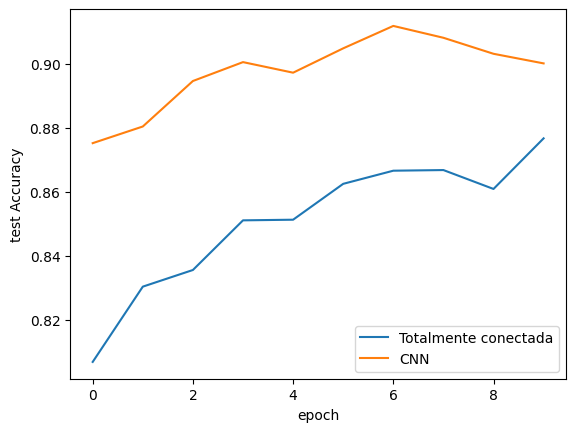

In [11]:
# Visualización de la exactitud en prueba para comparar FC vs CNN.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='Totalmente conectada')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')

#### **3. Funciones de activación y derivadas**

Aquí se visualizan varias activaciones y sus derivadas para entender:
- saturación de `sigmoid` y `tanh`
- comportamiento de `ReLU`
- ventaja práctica de `LeakyReLU` para evitar neuronas muertas


<Axes: >

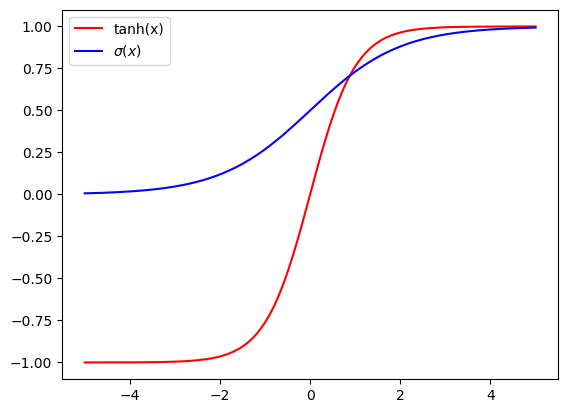

In [12]:
# Definición y visualización de funciones de activación suaves.
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

activation_input = np.linspace(-5, 5, num=200)
tanh_activation = np.tanh(activation_input)
sigmoid_activation = sigmoid(activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label="tanh(x)")
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label="$\sigma(x)$")


<Axes: >

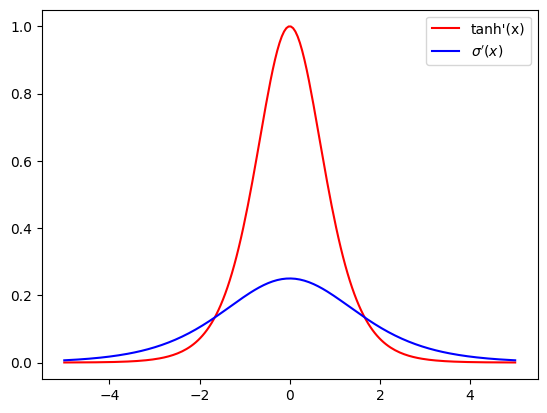

In [13]:
# Cálculo y visualización de derivadas para analizar el flujo del gradiente.
def tanh_derivative(x):
    return 1.0 - np.tanh(x)**2

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

tanh_derivative_values = tanh_derivative(activation_input)
sigmoid_derivative_values = sigmoid_derivative(activation_input)

sns.lineplot(x=activation_input, y=tanh_derivative_values, color='red', label="tanh'(x)")
sns.lineplot(x=activation_input, y=sigmoid_derivative_values, color='blue', label="$\sigma'(x)$")


<Axes: >

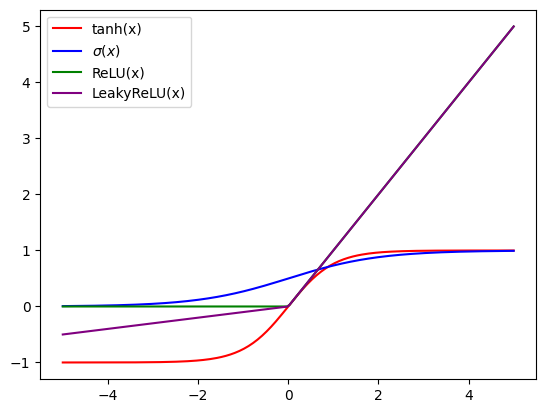

In [14]:
# Comparación visual entre activaciones clásicas y ReLU/LeakyReLU.
activation_input = np.linspace(-5, 5, num=200)
relu_activation = np.maximum(0, activation_input)
leaky_relu_activation = np.maximum(0.1 * activation_input, activation_input)

sns.lineplot(x=activation_input, y=tanh_activation, color='red', label="tanh(x)")
sns.lineplot(x=activation_input, y=sigmoid_activation, color='blue', label="$\sigma(x)$")
sns.lineplot(x=activation_input, y=relu_activation, color='green', label="ReLU(x)")
sns.lineplot(x=activation_input, y=leaky_relu_activation, color='purple', label="LeakyReLU(x)")


<Axes: >

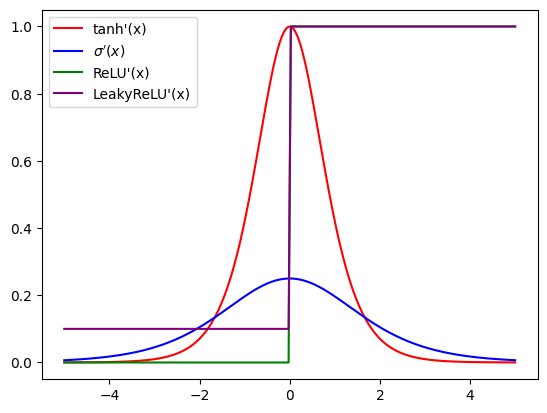

In [15]:
# Comparación de derivadas para entender saturación y estabilidad del gradiente.
relu_deriv = 1.0 * (activation_input > 0)
leaky_deriv = 1.0 * (activation_input > 0) + 0.1 * (activation_input <= 0)

sns.lineplot(x=activation_input, y=tanh_derivative_values, color='red', label="tanh'(x)")
sns.lineplot(x=activation_input, y=sigmoid_derivative_values, color='blue', label="$\sigma'(x)$")
sns.lineplot(x=activation_input, y=relu_deriv, color='green', label="ReLU'(x)")
sns.lineplot(x=activation_input, y=leaky_deriv, color='purple', label="LeakyReLU'(x)")


In [16]:
# Parámetro de fuga de LeakyReLU.
leak_rate = 0.1  # Valor consistente con las gráficas anteriores.


#### **4. Sustitución por LeakyReLU**

Ahora se reemplazan las activaciones `tanh` por `LeakyReLU` para estudiar el efecto sobre el entrenamiento.


In [17]:
# Red totalmente conectada usando LeakyReLU en lugar de tanh.
fc_relu_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n,  n), nn.LeakyReLU(leak_rate)) for _ in range(5)], 
    nn.Linear(n, classes),
)

In [18]:
# Función auxiliar para construir bloques convolucionales con LeakyReLU.
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    """
    in_filters: cuántos canales entran a la capa
    out_filters: cuántos canales debe producir la capa, o `None` si queremos mantener el mismo número de canales que la entrada.
    kernel_size: tamaño del kernel
    """
    if out_filters is None:
        out_filters = in_filters 
    padding=kernel_size//2 
    return nn.Sequential( 
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding), 
        nn.LeakyReLU(leak_rate)
    )

In [19]:
# CNN modular basada en la función auxiliar anterior.
cnn_relu_model = nn.Sequential(
    cnnLayer(C, n_filters), cnnLayer(n_filters), cnnLayer(n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(n_filters, 2*n_filters), cnnLayer(2*n_filters), cnnLayer(2*n_filters), 
    nn.MaxPool2d((2,2)),
    cnnLayer(2*n_filters, 4*n_filters), cnnLayer(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)


In [20]:
# Entrenamiento de los modelos con LeakyReLU y limpieza de memoria.
fc_relu_results = train_network(fc_relu_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del fc_relu_model
cnn_relu_results = train_network(cnn_relu_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del cnn_relu_model

Tiempo total de entrenamiento: 33.80 segundos
Tiempo total de entrenamiento: 440.62 segundos


<Axes: xlabel='epoch', ylabel='test Accuracy'>

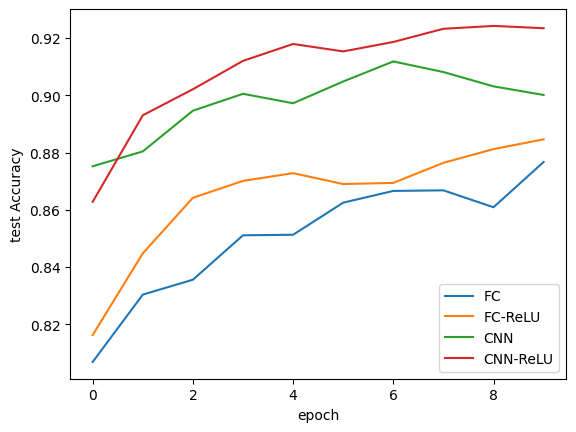

In [21]:
# Comparación de desempeño entre activaciones anteriores y LeakyReLU.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_results, label='FC')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_relu_results, label='FC-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')

#### **5. Batch Normalization**

En esta sección se añade **BatchNorm** a redes densas y convolucionales.  
El objetivo es estabilizar activaciones internas y facilitar el entrenamiento profundo.


In [22]:
# Red densa con Batch Normalization para estabilizar activaciones.
fc_bn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.BatchNorm1d(n), nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n,  n), nn.BatchNorm1d(n), nn.LeakyReLU(leak_rate)) for _ in range(5)], 
    nn.Linear(n, classes),
)

In [23]:
# Bloque convolucional que incorpora BatchNorm2d después de cada convolución.
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    if out_filters is None:
        out_filters = in_filters 
    padding=kernel_size//2 
    return nn.Sequential( 
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding), 
        nn.BatchNorm2d(out_filters), # El único cambio: añadimos BatchNorm2d después de la convolución.
        nn.LeakyReLU(leak_rate)
    )

In [24]:
# CNN con Batch Normalization.
cnn_bn_model = nn.Sequential(
    cnnLayer(C, n_filters), cnnLayer(n_filters), cnnLayer(n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(n_filters, 2*n_filters), cnnLayer(2*n_filters), cnnLayer(2*n_filters), 
    nn.MaxPool2d((2,2)),
    cnnLayer(2*n_filters, 4*n_filters), cnnLayer(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

In [25]:
# Entrenamiento de modelos con BatchNorm.
fc_bn_results = train_network(fc_bn_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del fc_bn_model
cnn_bn_results = train_network(cnn_bn_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del cnn_bn_model

Tiempo total de entrenamiento: 40.73 segundos
Tiempo total de entrenamiento: 499.70 segundos


<Axes: xlabel='epoch', ylabel='test Accuracy'>

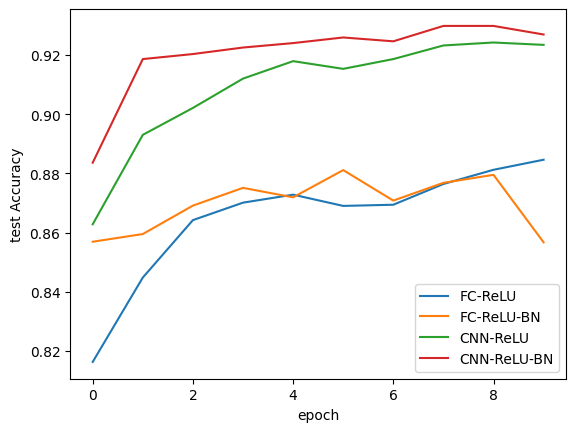

In [26]:
# Comparación entre modelos con y sin BatchNorm.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_relu_results, label='FC-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_results, label='FC-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_results, label='CNN-ReLU-BN')

#### **6. Layer Normalization**

Aquí se explora **LayerNorm** como alternativa a BatchNorm, especialmente útil cuando el tamaño del lote es pequeño o variable.


In [27]:
# Red densa con Layer Normalization.
fc_ln_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D,  n), nn.LayerNorm([n]), nn.LeakyReLU(leak_rate),
    *[nn.Sequential(nn.Linear(n,  n), nn.LayerNorm([n]), nn.LeakyReLU(leak_rate)) for _ in range(5)], 
    nn.Linear(n, classes),
)

In [28]:
# Bloque convolucional con LayerNorm ajustado al tamaño espacial de la activación.
def cnnLayer(in_filters, out_filters=None, pool_factor=0,kernel_size=3):
    if out_filters is None:
        out_filters = in_filters 
    padding=kernel_size//2 
    return nn.Sequential( 
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding), 
        nn.LayerNorm([out_filters, W//(2**pool_factor), H//(2**pool_factor)]), 
    )

In [29]:
# CNN con Layer Normalization.
cnn_ln_model = nn.Sequential(
    cnnLayer(C, n_filters), 
    cnnLayer(n_filters), 
    cnnLayer(n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(n_filters, 2*n_filters, pool_factor=1), 
    cnnLayer(2*n_filters, pool_factor=1), 
    cnnLayer(2*n_filters, pool_factor=1), 
    nn.MaxPool2d((2,2)), 
    cnnLayer(2*n_filters, 4*n_filters, pool_factor=2), 
    cnnLayer(4*n_filters, pool_factor=2),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

In [30]:
# Entrenamiento de modelos con LayerNorm.
fc_ln_results = train_network(fc_ln_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del fc_ln_model
cnn_ln_results = train_network(cnn_ln_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del cnn_ln_model

Tiempo total de entrenamiento: 36.44 segundos
Tiempo total de entrenamiento: 473.78 segundos


<Axes: xlabel='epoch', ylabel='test Accuracy'>

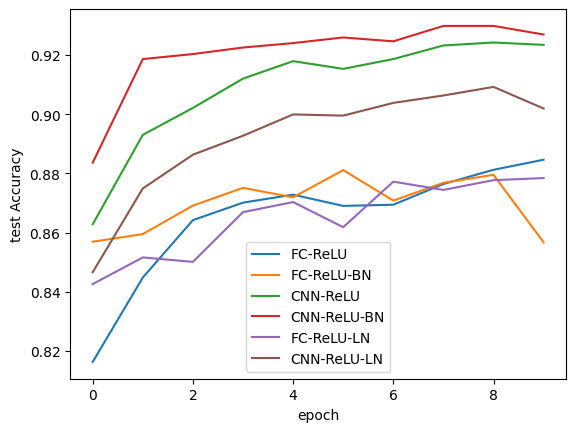

In [31]:
# Comparación entre variantes con ReLU, BatchNorm y LayerNorm.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_relu_results, label='FC-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_results, label='FC-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_results, label='CNN-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_ln_results, label='FC-ReLU-LN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_ln_results, label='CNN-ReLU-LN')

#### **6.5. Regularización adicional**

Presentamos tres ideas que vale la pena dejar explícitas en código:

- **L2/weight decay**: penaliza pesos grandes para favorecer modelos más simples y reducir sobreajuste.
- **Dropout**: apaga aleatoriamente una fracción de activaciones durante entrenamiento para evitar coadaptación excesiva.
- **Early stopping**: detiene el entrenamiento cuando la pérdida de validación deja de mejorar.

Estas técnicas complementan lo ya visto en **Batch Normalization**, **optimizadores modernos** y la transición posterior hacia **RNN/LSTM**.

##### **L2/weight decay**

En optimización clásica, la regularización **L2** suele implementarse mediante el parámetro `weight_decay` del optimizador.  
En **AdamW**, el *weight decay* está desacoplado del gradiente y por eso se considera una versión moderna más estable que la variante ingenua dentro de Adam.

In [32]:
# Ejemplo base para regularización L2/weight decay.
# Reutilizamos una red densa sencilla para mostrar cómo cambia el optimizador.

fc_l2_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n), nn.LeakyReLU(leak_rate),
    nn.Linear(n, n), nn.LeakyReLU(leak_rate),
    nn.Linear(n, classes),
)

# Opción 1: SGD con momentum y penalización L2 clásica.
optimizer_sgd_l2 = torch.optim.SGD(
    fc_l2_model.parameters(),
    lr=0.05,
    momentum=0.9,
    weight_decay=1e-4,  # Penalización sobre los pesos
)

# Opción 2: AdamW, muy usado en práctica moderna.
optimizer_adamw_l2 = torch.optim.AdamW(
    fc_l2_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,  # Weight decay desacoplado
)

print("Optimizador con L2 clásica:", optimizer_sgd_l2)
print("Optimizador moderno con weight decay:", optimizer_adamw_l2)

Optimizador con L2 clásica: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.05
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0001
)
Optimizador moderno con weight decay: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


##### **Dropout**

`Dropout(p)` desactiva aleatoriamente una fracción `p` de activaciones **solo durante entrenamiento**.  
En evaluación, la red usa todas las neuronas activas y PyTorch ajusta internamente la escala para mantener consistencia.

In [33]:
# Ejemplo de red densa con BatchNorm + Dropout.
# Esta combinación es útil para discutir regularización y generalización

drop_rate = 0.30

fc_dropout_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.BatchNorm1d(n),
    nn.LeakyReLU(leak_rate),
    nn.Dropout(drop_rate),   # Durante entrenamiento apaga aleatoriamente parte de las activaciones

    nn.Linear(n, n),
    nn.BatchNorm1d(n),
    nn.LeakyReLU(leak_rate),
    nn.Dropout(drop_rate),

    nn.Linear(n, classes),
)

print(fc_dropout_model)

# Pequeña comprobación: la forma de salida no cambia aunque el comportamiento interno sí.
x_demo = torch.randn(8, 1, 28, 28)

fc_dropout_model.train()
y_train_mode = fc_dropout_model(x_demo)

fc_dropout_model.eval()
y_eval_mode = fc_dropout_model(x_demo)

print("Salida en modo entrenamiento:", y_train_mode.shape)
print("Salida en modo evaluación:", y_eval_mode.shape)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): LeakyReLU(negative_slope=0.1)
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=256, bias=True)
  (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): LeakyReLU(negative_slope=0.1)
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=256, out_features=10, bias=True)
)
Salida en modo entrenamiento: torch.Size([8, 10])
Salida en modo evaluación: torch.Size([8, 10])


##### **Early stopping**

La idea es vigilar una métrica de **validación** y detener el entrenamiento cuando ya no mejora después de cierta paciencia (`patience`).  
Esto evita seguir ajustando el modelo cuando empieza a memorizar ruido o cuando la mejora adicional ya no compensa el costo.

In [34]:
# Preparamos una partición train/validation para ilustrar early stopping.
# Usamos una parte del conjunto de entrenamiento como validación.

train_size = int(0.9 * len(train_data))
val_size = len(train_data) - train_size

train_subset, val_subset = torch.utils.data.random_split(
    train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader_es = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader_es = DataLoader(val_subset, batch_size=128, shuffle=False)

def evaluate_loss(model, loader, loss_func, device):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = loss_func(logits, yb)

            batch_size = xb.shape[0]
            total_loss += loss.item() * batch_size
            total_items += batch_size

    return total_loss / total_items

def train_with_early_stopping(model, train_loader, val_loader, optimizer, loss_func,
                              device, max_epochs=20, patience=3, min_delta=1e-4):
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    history = []

    model.to(device)

    for epoch in range(max_epochs):
        model.train()
        total_train_loss = 0.0
        total_items = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_func(logits, yb)
            loss.backward()
            optimizer.step()

            batch_size = xb.shape[0]
            total_train_loss += loss.item() * batch_size
            total_items += batch_size

        train_loss = total_train_loss / total_items
        val_loss = evaluate_loss(model, val_loader, loss_func, device)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        # Guardamos el mejor estado del modelo según validación.
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Entrenamiento detenido en la época {epoch + 1} por early stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)

# Modelo de ejemplo que combina BatchNorm, Dropout y AdamW con weight decay.
# Dejamos la ejecución pesada desactivada por defecto para que el cuaderno siga siendo ligero.
RUN_EARLY_STOPPING_DEMO = False

early_stop_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D, n),
    nn.BatchNorm1d(n),
    nn.LeakyReLU(leak_rate),
    nn.Dropout(0.30),
    nn.Linear(n, n),
    nn.LeakyReLU(leak_rate),
    nn.Dropout(0.30),
    nn.Linear(n, classes),
)

early_stop_optimizer = torch.optim.AdamW(
    early_stop_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

if RUN_EARLY_STOPPING_DEMO:
    early_stop_history = train_with_early_stopping(
        early_stop_model,
        train_loader_es,
        val_loader_es,
        optimizer=early_stop_optimizer,
        loss_func=loss_func,
        device=device,
        max_epochs=20,
        patience=3,
    )
    display(early_stop_history)
else:
    print("Pon RUN_EARLY_STOPPING_DEMO = True si quieres ejecutar la demostración completa.")

Pon RUN_EARLY_STOPPING_DEMO = True si quieres ejecutar la demostración completa.


#### **7. conexiones residuales en capas totalmente conectadas**

Estas celdas muestran cómo combinar activaciones intermedias para mejorar el flujo de información y del gradiente.


In [35]:
# Definición de un bloque denso con conexiones residuales.
class SkipFC(nn.Module):
    def __init__(self, n_layers, in_size, out_size, leak_rate=0.1):
        """
        n_layers: número de capas ocultas en este bloque denso con conexiones residuales
        in_size: cuántas características entran a esta capa
        out_size: cuántas características debe producir la capa final de este bloque.  
        leak_rate: parámetro de la activación LeakyReLU. 
        """
        super().__init__()
        
        l = n_layers-1
        self.layers = nn.ModuleList([nn.Linear(in_size*l, out_size) if i == l else nn.Linear(in_size, in_size) for i in range(n_layers)])
        self.bns = nn.ModuleList([nn.BatchNorm1d(out_size) if i == l else nn.BatchNorm1d(in_size) for i in range(n_layers)])
        self.activation = nn.LeakyReLU(leak_rate)
    
    def forward(self, x):
        activations = []
        
        for layer, bn in zip(self.layers[:-1], self.bns[:-1]):
            x = self.activation(bn(layer(x)))
            activations.append( x )
        x = torch.cat(activations, dim=1)
        return self.activation(self.bns[-1](self.layers[-1](x)))

In [36]:
# Modelo totalmente conectado con bloques residuales.
fc_skip_model = nn.Sequential(
    nn.Flatten(),
    SkipFC(2, D, n),
    SkipFC(2, n, n),
    SkipFC(2, n, n),
    nn.Linear(n, classes),
)

fc_skip_results = train_network(fc_skip_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del fc_skip_model

Tiempo total de entrenamiento: 52.60 segundos


<Axes: xlabel='epoch', ylabel='test Accuracy'>

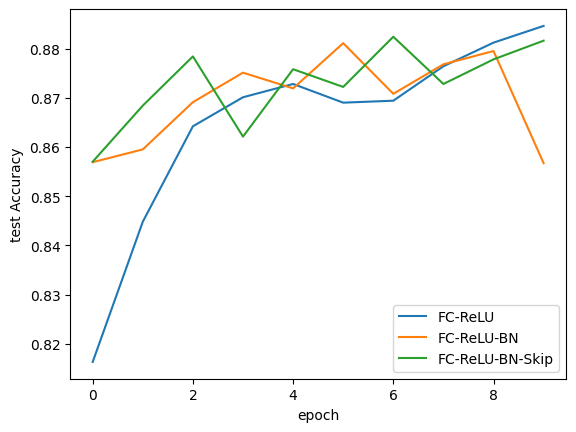

In [37]:
# Comparación de desempeño al añadir conexiones residuales en la red densa.
sns.lineplot(x='epoch', y='test Accuracy', data=fc_relu_results, label='FC-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_bn_results, label='FC-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=fc_skip_results, label='FC-ReLU-BN-Skip')

#### **8. Conexiones residuales en CNN**

La misma idea de conexiones de salto se lleva ahora al caso convolucional.


In [38]:
# Definición de un bloque convolucional con conexiones residuales.
class SkipConv2d(nn.Module):
    def __init__(self, n_layers, in_channels, out_channels, kernel_size=3, leak_rate=0.1):
        super().__init__()
        
        l = n_layers-1
        # Valores auxiliares sencillos
        f = (kernel_size, kernel_size)
        pad = (kernel_size-1)//2
        
        self.layers = nn.ModuleList([nn.Conv2d(in_channels*l, out_channels, kernel_size=f, padding=pad) if i == l else nn.Conv2d(in_channels, in_channels, kernel_size=f, padding=pad) for i in range(n_layers)])
        self.bns = nn.ModuleList([nn.BatchNorm2d(out_channels) if i == l else nn.BatchNorm2d(in_channels) for i in range(n_layers)])
        
        self.activation = nn.LeakyReLU(leak_rate)
    
    def forward(self, x):
        # Este código es análogo a `SkipFC`, pero vale la pena resaltar la línea más importante que cambia.
        activations = []
        
        for layer, bn in zip(self.layers[:-1], self.bns[:-1]):
            x = self.activation(bn(layer(x)))
            activations.append( x )
        # Aquí concatenamos todas las activaciones. 
        x = torch.cat(activations, dim=1)
        
        return self.activation(self.bns[-1](self.layers[-1](x)))

In [39]:
# CNN con bloques residuales.
cnn_skip_model = nn.Sequential(
    nn.Conv2d(C, n_filters, (3,3), padding=1), 
    SkipConv2d(3, n_filters, 2*n_filters),
    nn.MaxPool2d((2,2)),
    nn.LeakyReLU(),
    SkipConv2d(3, 2*n_filters, 4*n_filters),
    nn.MaxPool2d((2,2)),
    SkipConv2d(2, 4*n_filters, 4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

cnn_skip_results = train_network(cnn_skip_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del cnn_skip_model

Tiempo total de entrenamiento: 905.43 segundos


<Axes: xlabel='epoch', ylabel='test Accuracy'>

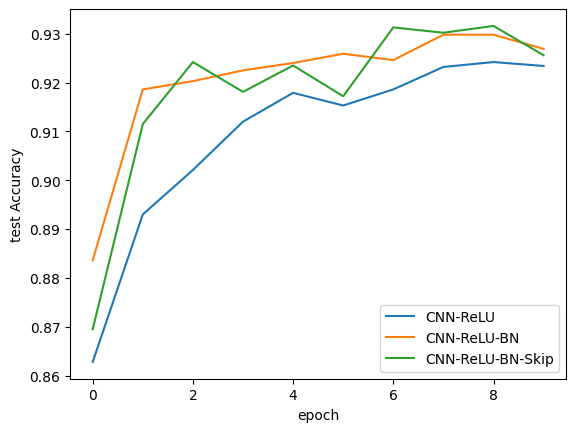

In [40]:
# Comparación de desempeño al añadir conexiones residuales en la CNN.
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_results, label='CNN-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_skip_results, label='CNN-ReLU-BN-Skip')

#### **9. Convoluciones `1x1` e intercambio de información entre canales**

Las capas `1x1` permiten mezclar información entre canales sin modificar la resolución espacial.


In [41]:
# Bloque 1x1 para compartir información entre canales.
def infoShareBlock(n_filters):
    return nn.Sequential(
        nn.Conv2d(n_filters, n_filters, (1,1), padding=0), 
        nn.BatchNorm2d(n_filters),
        nn.LeakyReLU())

In [42]:
# Bloque convolucional base reutilizado junto con las capas 1x1.
def cnnLayer(in_filters, out_filters=None, kernel_size=3):
    if out_filters is None:
        out_filters = in_filters
    padding=kernel_size//2
    return nn.Sequential( 
        nn.Conv2d(in_filters, out_filters, kernel_size, padding=padding), 
        nn.BatchNorm2d(out_filters), 
        nn.LeakyReLU(leak_rate)
    )

In [43]:
# CNN que combina convoluciones estándar con bloques 1x1.
cnn_1x1_model = nn.Sequential(
    cnnLayer(C, n_filters), 
    cnnLayer(n_filters),
    infoShareBlock(n_filters),
    cnnLayer(n_filters),
    nn.MaxPool2d((2,2)),
    cnnLayer(n_filters, 2*n_filters), 
    cnnLayer(2*n_filters),
    infoShareBlock(2*n_filters),
    cnnLayer(2*n_filters), 
    nn.MaxPool2d((2,2)),
    cnnLayer(2*n_filters, 4*n_filters), 
    cnnLayer(4*n_filters),
    infoShareBlock(4*n_filters),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)
cnn_1x1_results = train_network(cnn_1x1_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)
del cnn_1x1_model

Tiempo total de entrenamiento: 524.62 segundos


<Axes: xlabel='epoch', ylabel='test Accuracy'>

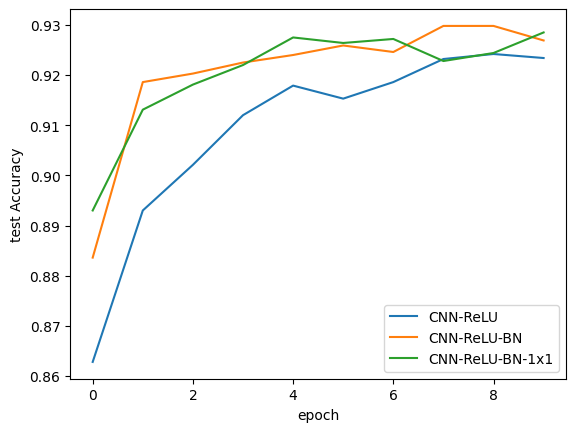

In [44]:
# Comparación del modelo con bloques 1x1 frente a otras CNN.
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_results, label='CNN-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_1x1_results, label='CNN-ReLU-BN-1x1')

#### **10. Bloques residuales**

Aquí aparecen bloques residuales tipo ResNet:
- camino principal con convoluciones
- atajo (*shortcut*)
- suma de ambos caminos para facilitar el entrenamiento de redes profundas


In [45]:
# Bloque residual simple con dos convoluciones.
class ResidualBlockE(nn.Module):
    def __init__(self, channels, kernel_size=3, leak_rate=0.1):
        """
        channels: cuántos canales tiene la entrada/salida de esta capa
        kernel_size: tamaño del filtro que vamos a usar
        leak_rate: parámetro de la activación LeakyReLU
        """
        super().__init__()
        # Cuánto padding necesitan las convoluciones para mantener la forma de entrada
        pad = (kernel_size-1)//2
        
        # Definimos las capas convolucionales y de batch norm que usará la subred: dos capas ocultas conv/BN/activación
        self.F = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(leak_rate),
        )
     
    def forward(self, x):
        return x + self.F(x) # `F()` realiza el trabajo del camino largo; aquí solo lo sumamos a la entrada

In [46]:
# Bloque residual tipo bottleneck para cambiar canales y mantener la idea de shortcut.
class ResidualBottleNeck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, leak_rate=0.1):
        super().__init__()
        
        pad = (kernel_size-1)//2
        bottleneck = max(out_channels//4, in_channels)

        self.F = nn.Sequential(
            # Reducimos dimensionalidad
            nn.BatchNorm2d(in_channels),
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(in_channels, bottleneck, 1, padding=0),
            # Capa intermedia con convolución completa
            nn.BatchNorm2d(bottleneck),
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(bottleneck, bottleneck, kernel_size, padding=pad),
            # Volvemos a expandir
            nn.BatchNorm2d(bottleneck),
            nn.LeakyReLU(leak_rate),
            nn.Conv2d(bottleneck, out_channels, 1, padding=0)
        )

        # Por defecto, el atajo (*shortcut*) es la función identidad, que devuelve la entrada sin cambios
        self.shortcut = nn.Identity()
        
        if in_channels != out_channels:
            self.shortcut =  nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, 1, padding=0), 
                    nn.BatchNorm2d(out_channels)
                )

    def forward(self, x):
        return self.shortcut(x) + self.F(x) 

In [47]:
# Construcción de una CNN residual inspirada en ResNet.
cnn_res_model = nn.Sequential(
    ResidualBottleNeck(C, n_filters), 
    nn.LeakyReLU(leak_rate), 
    ResidualBlockE(n_filters),
    nn.LeakyReLU(leak_rate),
    nn.MaxPool2d((2,2)),
    ResidualBottleNeck(n_filters, 2*n_filters),
    nn.LeakyReLU(leak_rate),
    ResidualBlockE(2*n_filters),
    nn.LeakyReLU(leak_rate),
    nn.MaxPool2d((2,2)),
    ResidualBottleNeck(2*n_filters, 4*n_filters),
    nn.LeakyReLU(leak_rate),
    ResidualBlockE(4*n_filters),
    nn.LeakyReLU(leak_rate),
    nn.Flatten(),
    nn.Linear(D*n_filters//4, classes),
)

In [48]:
# Entrenamiento del modelo residual.
cnn_res_results = train_network(cnn_res_model, loss_func, train_loader, test_loader=test_loader, epochs=10, score_funcs={'Accuracy': accuracy_score}, device=device, disable_tqdm=True)

Tiempo total de entrenamiento: 710.52 segundos


<Axes: xlabel='epoch', ylabel='test Accuracy'>

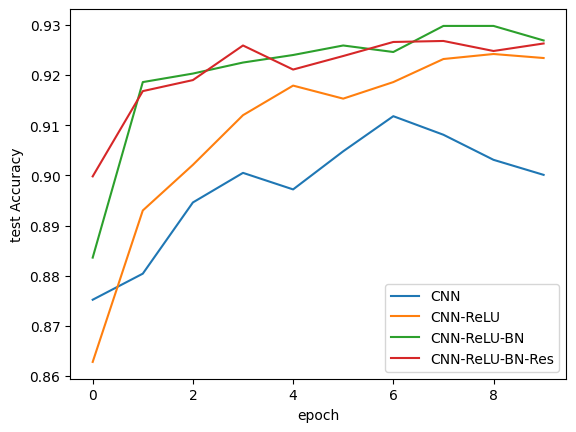

In [49]:
# Comparación del desempeño de la CNN residual frente a otras variantes.
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_results, label='CNN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_relu_results, label='CNN-ReLU')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_bn_results, label='CNN-ReLU-BN')
sns.lineplot(x='epoch', y='test Accuracy', data=cnn_res_results, label='CNN-ReLU-BN-Res')

#### **11. Datos secuenciales: clasificación de nombres por idioma**

Se descarga un conjunto de nombres y se prepara una tarea de secuencias para comparar **RNN** y **LSTM**.


In [50]:
# Descarga y preprocesamiento de un conjunto de nombres por idioma.
zip_file_url = "https://download.pytorch.org/tutorial/data.zip"

import requests, zipfile, io
r = requests.get(zip_file_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()
name_language_data = {}

# Usaremos código para eliminar caracteres Unicode y simplificar el procesamiento
# Por ejemplo, convertir algo como "Ślusàrski" en `Slusarski`
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)
alphabet = {}
for i in range(n_letters):
    alphabet[all_letters[i]] = i
    
# Convierte una cadena Unicode en ASCII simple
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )


# Recorremos cada idioma, abrimos el archivo dentro del zip y leemos todas sus líneas.
for zip_path in z.namelist():
    if "data/names/" in zip_path and zip_path.endswith(".txt"):
        lang = zip_path[len("data/names/"):-len(".txt")]
        with z.open(zip_path) as myfile:
            lang_names = [unicodeToAscii(line).lower() for line in str(myfile.read(), encoding='utf-8').strip().split("\n")]
            name_language_data[lang] = lang_names 

In [51]:
# Construcción del dataset secuencial y de los dataloaders para entrenamiento y prueba.
dataset = LanguageNameDataset(name_language_data, alphabet) 

train_lang_data, test_lang_data = torch.utils.data.random_split(
    dataset,
    (len(dataset) - 300, 300),
    generator=torch.Generator().manual_seed(42),
)
train_lang_loader = DataLoader(train_lang_data, batch_size=32, shuffle=True, collate_fn=pad_and_pack)
test_lang_loader = DataLoader(test_lang_data, batch_size=32, shuffle=False, collate_fn=pad_and_pack)


In [52]:
# Volvemos a fijar la semilla antes del experimento secuencial.
set_seed(42)

#### **12. Comparación RNN vs LSTM**

Esta parte conecta con el curso a:
- una **RNN** simple puede sufrir más con dependencias largas y estabilidad del gradiente
- una **LSTM** mejora el manejo de memoria y suele entrenar mejor en secuencias

Esto ayuda a justificar la transición posterior hacia **mecanismos de atención**.


In [53]:
# Definición y entrenamiento de una RNN de 3 capas con gradient clipping.
rnn_3layer = nn.Sequential( # RNN clásica de estilo secuencial 
  EmbeddingPackable(nn.Embedding(len(all_letters), 64)), #(B, T) -> (B, T, D)
  nn.RNN(64, n, num_layers=3, batch_first=True), #(B, T, D) -> ( (B,T,D) , (S, B, D)  )
  LastTimeStep(rnn_layers=3), # Reducimos la salida de la RNN a un único vector por ejemplo, `(B, D)`
  nn.Linear(n, len(name_language_data)), #(B, D) -> (B, classes)
)

# Aplicamos *gradient clipping* para estabilizar el entrenamiento
for p in rnn_3layer.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -5, 5))

rnn_results = train_network(rnn_3layer, loss_func, train_lang_loader, test_loader=test_lang_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10, disable_tqdm=True)

Tiempo total de entrenamiento: 353.89 segundos


In [54]:
# Definición y entrenamiento de una LSTM de 3 capas con gradient clipping.
lstm_3layer = nn.Sequential(
  EmbeddingPackable(nn.Embedding(len(all_letters), 64)), #(B, T) -> (B, T, D)
  # Reemplazamos `nn.RNN` por `nn.LSTM` para pasar a una arquitectura con mejor manejo de memoria
  nn.LSTM(64, n, num_layers=3, batch_first=True), #(B, T, D) -> ( (B,T,D) , (S, B, D)  )
  LastTimeStep(rnn_layers=3), # Reducimos la salida de la RNN a un único vector por ejemplo, `(B, D)`
  nn.Linear(n, len(name_language_data)), #(B, D) -> (B, classes)
)
# Seguimos usando *gradient clipping* en cualquier tipo de RNN, incluidas las LSTM
for p in lstm_3layer.parameters():
    p.register_hook(lambda grad: torch.clamp(grad, -5, 5))

lstm_results = train_network(lstm_3layer, loss_func, train_lang_loader, test_loader=test_lang_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10, disable_tqdm=True)

Tiempo total de entrenamiento: 175.58 segundos


#### **13. Lectura conceptual**

La comparación final entre RNN y LSTM sirve como puente conceptual:

- **RNN**: procesa de forma secuencial y puede degradarse en secuencias largas.
- **LSTM**: mejora la memoria mediante compuertas, pero sigue siendo secuencial.
- **Atención**: surge como respuesta a estas limitaciones, permitiendo que cada token consulte directamente otros elementos relevantes de la secuencia.




<Axes: xlabel='epoch', ylabel='test Accuracy'>

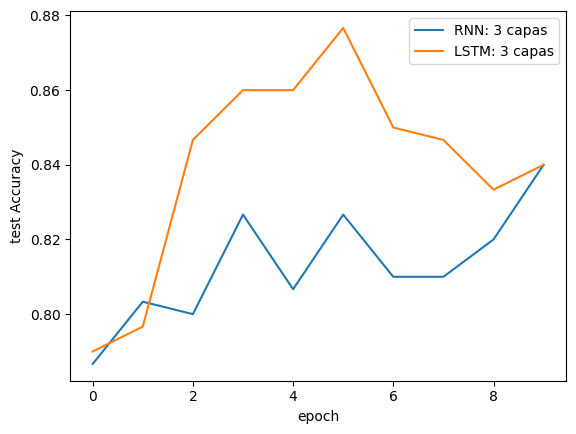

In [55]:
# Comparación final entre RNN y LSTM en exactitud de prueba.
sns.lineplot(x='epoch', y='test Accuracy', data=rnn_results, label='RNN: 3 capas')
sns.lineplot(x='epoch', y='test Accuracy', data=lstm_results, label='LSTM: 3 capas')


#### **14. Ejercicios**


1. **Comparación base: red fully connected vs CNN**
   Entrena nuevamente `fc_model` y `cnn_model` con los mismos hiperparámetros del cuaderno. Luego explica:

   * cuál converge más rápido,
   * cuál obtiene mejor `test Accuracy`,
   * por qué una CNN suele funcionar mejor que una red totalmente conectada en FashionMNIST.

2. **Análisis de funciones de activación**
   Reproduce las gráficas de `sigmoid`, `tanh`, `ReLU` y `LeakyReLU` junto con sus derivadas. Después responde:

   * ¿en qué zonas aparece saturación?
   * ¿qué activación favorece mejor el flujo del gradiente?
   * ¿por qué `LeakyReLU` puede ser preferible a `ReLU`?

3. **Sustitución de `tanh` por `LeakyReLU`**
   Modifica `fc_model` y `cnn_model` para reemplazar todas las activaciones `tanh` por `LeakyReLU`, tal como se hace en `fc_relu_model` y `cnn_relu_model`. Compara los resultados con los modelos originales y redacta una conclusión sobre el impacto del cambio.

4. **Efecto del parámetro `leak_rate`**
   Entrena el modelo `fc_relu_model` usando al menos tres valores distintos de `leak_rate` (por ejemplo: `0.01`, `0.1` y `0.3`). Grafica los resultados y determina cuál valor ofrece mejor equilibrio entre estabilidad y rendimiento.

5. **BatchNorm vs LayerNorm**
   Usa `fc_bn_model`, `cnn_bn_model`, `fc_ln_model` y `cnn_ln_model` para comparar normalización por lote y por capa. Elabora una tabla con:

   * accuracy final,
   * velocidad de convergencia,
   * comportamiento observado durante el entrenamiento.
     Finalmente, explica en qué casos preferirías `BatchNorm` y en cuáles `LayerNorm`.

6. **Regularización: Dropout, L2 y Early Stopping**
   A partir de `fc_dropout_model`, `fc_l2_model` y la partición train/validation del cuaderno, diseña tres experimentos:

   * solo `Dropout`,
   * solo `weight_decay`,
   * combinación de ambos con `early stopping`.
     Compara los resultados y responde cuál estrategia reduce mejor el sobreajuste.

7. **conexiones residuales y bloques residuales**
   Entrena y compara:

   * `fc_skip_model`,
   * `cnn_skip_model`,
   * `cnn_res_model`.
     Explica qué problema intentan resolver las conexiones residuales y analiza si en este cuaderno mejoran realmente el desempeño respecto a los modelos sin atajos.

8. **RNN vs LSTM en datos secuenciales**
   Usa `rnn_3layer` y `lstm_3layer` para comparar ambas arquitecturas en la clasificación de nombres por idioma. Luego responde:

   * ¿cuál obtiene mejor accuracy?
   * ¿cuál parece manejar mejor dependencias largas?
   * ¿por qué la LSTM suele superar a una RNN simple en este tipo de tarea?



In [ ]:
## Tus respuestas